In [2]:
#from B_1 import *
# from B_plot_funcs import *
from a_NN_Samplers_and_VI_algo import * 

In [3]:
def banana_loss_surface(loss_fn, W1, W2):
    theta_batch = torch.tensor(
        np.stack([W1.ravel(), W2.ravel()], axis=1),
        dtype=torch.float64)
    with torch.no_grad():
        Z = loss_fn.Loss_batch(theta_batch).numpy()
    return Z.reshape(W1.shape)

In [4]:
from matplotlib.lines import Line2D

In [5]:
def plot_one_walk_types(loss_fn,metric,starts=[(0.3, 0.3), (-2, 0), (2, -2)],walk_len=50,step_size=0.001,seed=7,w1_range=[-5, 5],w2_range=[-5, 5],grid_n=500):
    
    # sampler = Brownian_sampler(metric, walk_len=walk_len, step_size=step_size)
    sampler_eu = Euclidean_sampler(walk_len=walk_len, step_size=step_size)

    plt.figure(figsize=(12, 10))

    plt.rcParams.update({
        "font.size": 14,
        "axes.titlesize": 18,
        "axes.labelsize": 16,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "legend.fontsize": 13})

    w1 = np.linspace(w1_range[0], w1_range[1], grid_n)
    w2 = np.linspace(w2_range[0], w2_range[1], grid_n)
    W1, W2 = np.meshgrid(w1, w2)
    # Loss = loss_fct([W1, W2])

    Loss = banana_loss_surface(loss_fn, W1, W2)
    
    im = plt.imshow(
        Loss,
        extent=[w1.min(), w1.max(), w2.min(), w2.max()],
        origin="lower",
        aspect="auto",
        cmap="RdBu",
        alpha=0.5,
        vmin=0,
        vmax=2
    )

    cbar = plt.colorbar(im)
    cbar.set_label(r"$L(w_1,w_2)$", fontsize=15)
    cbar.ax.tick_params(labelsize=13)

    # PlotLoss = np.exp(-Loss)

    # im = plt.imshow(PlotLoss,extent=[w1.min(), w1.max(), w2.min(), w2.max()],origin="lower",aspect="auto",cmap="Reds_r",alpha=0.5)
    # cbar = plt.colorbar(im)
    # cbar.set_label(r"$\exp(-L(w_1,w_2))$", fontsize=15)

    # im = plt.imshow(Loss,extent=[w1.min(), w1.max(), w2.min(), w2.max()],origin="lower",aspect="auto",cmap="Reds",alpha=0.5)
    # # plt.colorbar(label=r"$L(w_1,w_2)$")
    # cbar = plt.colorbar(im)
    # cbar.ax.tick_params(labelsize=13)
    # cbar.set_label(r"$L(w_1,w_2)$", fontsize=15)


    colors = {"Euclidean": "royalblue"}

    for j, start in enumerate(starts):
        start_tensor = torch.tensor(start, dtype=torch.float64)

        EU = sampler_eu.compute_EU_walk(start_tensor,random_state=seed + 10*j).detach().numpy()

        #BM_no_drift = sampler.compute_BM(start_tensor,random_state=seed + 10*j,drift=False).detach().numpy()

        #BM_drift = sampler.compute_BM(start_tensor,random_state=seed + 10*j,drift=True).detach().numpy()


        walks = {"Euclidean": EU}

        for label, walk in walks.items():
            c = colors[label]

            plt.plot(walk[:, 0], walk[:, 1], color=c, linewidth=1.5)

            plt.scatter(walk[0, 0], walk[0, 1],c="black",s=45,zorder=5)

            plt.scatter(walk[-1, 0], walk[-1, 1],c=c,marker="*",s=200,edgecolor="black",linewidth=0.8,zorder=6)

    legend_handles = [
        Line2D([0], [0], color="royalblue", lw=2, label="Euclidean"),
        # Line2D([0], [0], color="gold", lw=2, label="Brownian no drift"),
        # Line2D([0], [0], color="limegreen", lw=2, label="Brownian with drift"),
        Line2D([0], [0], marker="o", color="black", linestyle="None",
               markersize=8, label="start"),
        Line2D([0], [0], marker="*", color="black", linestyle="None",
               markersize=12, label="end"),
    ]

    plt.legend(handles=legend_handles, loc="upper left", frameon=True)

    plt.xlabel(r"$w_1$", fontsize=16)
    plt.ylabel(r"$w_2$", fontsize=16)
    plt.title("Euclidean walks from different starting points",fontsize=18)

    plt.tight_layout()
    plt.show()

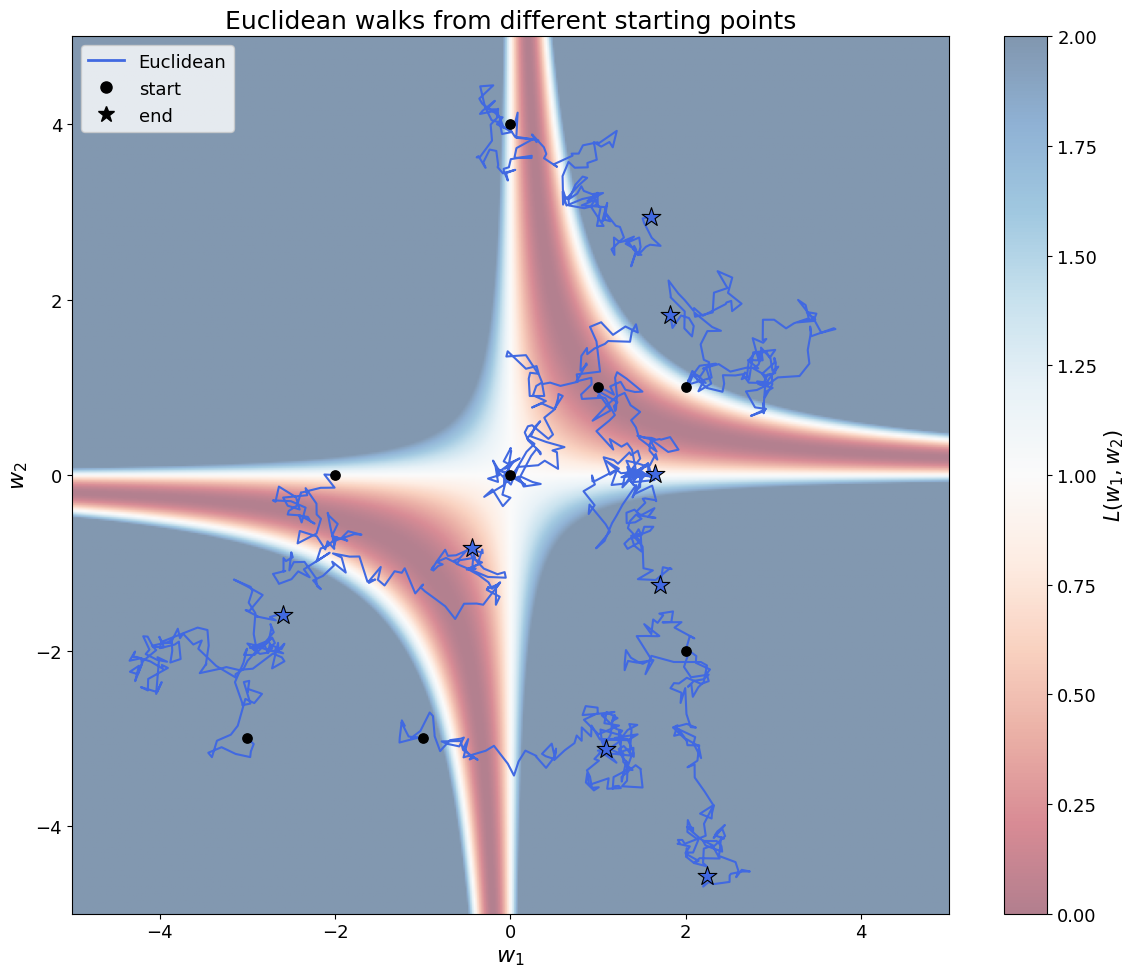

In [6]:
loss_fn = Losses_BANAN()
metric = RiemannianMetric(loss_fn)

plot_one_walk_types(
    loss_fn=loss_fn,
    metric=metric,
    starts=[(0.0, 0.0), (-2, 0), (2, -2), (1, 1), (0, 4), (2,1),(-1,-3), (-3,-3)],
    walk_len=150,
    step_size=0.01,
    seed=10)

In [7]:
def plot_two_walk_types(loss_fn,metric,starts=[(0.3, 0.3), (-2, 0), (2, -2)],walk_len=50,step_size=0.001,seed=7,w1_range=[-5, 5],w2_range=[-5, 5],grid_n=500):
    
    sampler = Brownian_sampler(metric, walk_len=walk_len, step_size=step_size)
    # sampler_eu = Euclidean_sampler(walk_len=walk_len, step_size=step_size)

    plt.figure(figsize=(12, 10))

    plt.rcParams.update({
        "font.size": 14,
        "axes.titlesize": 18,
        "axes.labelsize": 16,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "legend.fontsize": 13
    })

    w1 = np.linspace(w1_range[0], w1_range[1], grid_n)
    w2 = np.linspace(w2_range[0], w2_range[1], grid_n)
    W1, W2 = np.meshgrid(w1, w2)
    # Loss = loss_fct([W1, W2])

    Loss = banana_loss_surface(loss_fn, W1, W2)

    im = plt.imshow(
        Loss,
        extent=[w1.min(), w1.max(), w2.min(), w2.max()],
        origin="lower",
        aspect="auto",
        cmap="RdBu",
        alpha=0.5,
        vmin=0,
        vmax=2
    )

    cbar = plt.colorbar(im)
    cbar.set_label(r"$L(w_1,w_2)$", fontsize=15)
    cbar.ax.tick_params(labelsize=13)

    # PlotLoss = np.exp(-Loss)

    # im = plt.imshow(PlotLoss,extent=[w1.min(), w1.max(), w2.min(), w2.max()],origin="lower",aspect="auto",cmap="Reds_r",alpha=0.5)
    # cbar = plt.colorbar(im)
    # cbar.set_label(r"$\exp(-L(w_1,w_2))$", fontsize=15)

    # im = plt.imshow(Loss,extent=[w1.min(), w1.max(), w2.min(), w2.max()],origin="lower",aspect="auto",cmap="Reds",alpha=0.5)
    # # plt.colorbar(label=r"$L(w_1,w_2)$")
    # cbar = plt.colorbar(im)
    # cbar.ax.tick_params(labelsize=13)
    # cbar.set_label(r"$L(w_1,w_2)$", fontsize=15)


    colors = {"Brownian no drift": "gold",
              "Brownian with drift": "limegreen"}

    for j, start in enumerate(starts):
        start_tensor = torch.tensor(start, dtype=torch.float64)

        BM_no_drift = sampler.compute_BM(start_tensor,random_state=seed + 10*j,drift=False).detach().numpy()

        BM_drift = sampler.compute_BM(start_tensor,random_state=seed + 10*j,drift=True).detach().numpy()

        walks = {"Brownian no drift": BM_no_drift,
                 "Brownian with drift": BM_drift}

        for label, walk in walks.items():
            c = colors[label]

            plt.plot(walk[:, 0], walk[:, 1], color=c, linewidth=1.5)

            plt.scatter(walk[0, 0], walk[0, 1],c="black",s=45,zorder=5)

            plt.scatter(walk[-1, 0], walk[-1, 1],c=c,marker="*",s=200,edgecolor="black",linewidth=0.8,zorder=6)

    legend_handles = [
        Line2D([0], [0], color="gold", lw=2, label="Brownian no drift"),
        Line2D([0], [0], color="limegreen", lw=2, label="Brownian with drift"),
        Line2D([0], [0], marker="o", color="black", linestyle="None",
               markersize=8, label="start"),
        Line2D([0], [0], marker="*", color="black", linestyle="None",
               markersize=12, label="end"),
    ]

    plt.legend(handles=legend_handles, loc="upper left", frameon=True)

    plt.xlabel(r"$w_1$", fontsize=16)
    plt.ylabel(r"$w_2$", fontsize=16)
    plt.title("Brownian walks from different starting points",fontsize=18)

    plt.tight_layout()
    plt.show()

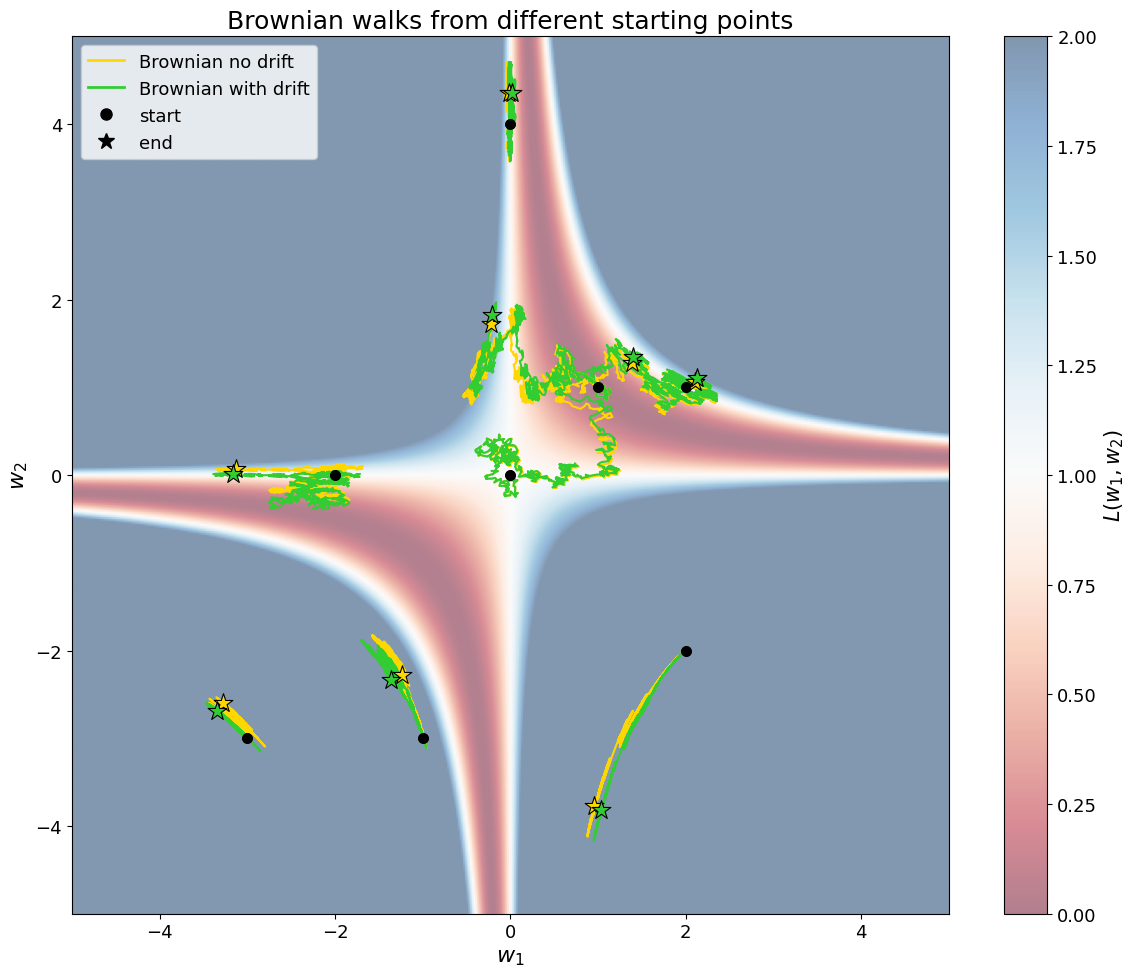

In [8]:
plot_two_walk_types(
    loss_fn=loss_fn,
    metric=metric,
    starts=[(0.0, 0.0), (-2, 0), (2, -2), (1, 1), (0, 4), (2,1),(-1,-3), (-3,-3)],
    walk_len=1000,
    step_size=0.001,
    seed=2)

In [9]:
def plot_three_walk_types(loss_fn,metric,starts=[(0.3, 0.3), (-2, 0), (2, -2)],walk_len=50,step_size=0.001,seed=7,w1_range=[-5, 5],w2_range=[-5, 6],grid_n=500):
    
    sampler = Brownian_sampler(metric, walk_len=walk_len, step_size=step_size)
    sampler_eu = Euclidean_sampler(walk_len=walk_len, step_size=step_size)

    plt.figure(figsize=(12, 10))

    plt.rcParams.update({
        "font.size": 14,
        "axes.titlesize": 18,
        "axes.labelsize": 16,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "legend.fontsize": 13
    })

    w1 = np.linspace(w1_range[0], w1_range[1], grid_n)
    w2 = np.linspace(w2_range[0], w2_range[1], grid_n)
    W1, W2 = np.meshgrid(w1, w2)
    # Loss = loss_fct([W1, W2])

    Loss = banana_loss_surface(loss_fn, W1, W2)

    im = plt.imshow(
        Loss,
        extent=[w1.min(), w1.max(), w2.min(), w2.max()],
        origin="lower",
        aspect="auto",
        cmap="RdBu",
        alpha=0.5,
        vmin=0,
        vmax=2
    )

    cbar = plt.colorbar(im)
    cbar.set_label(r"$L(w_1,w_2)$", fontsize=15)
    cbar.ax.tick_params(labelsize=13)

    colors = {"Euclidean": "royalblue",
              "Brownian no drift": "gold",
              "Brownian with drift": "limegreen"}

    for j, start in enumerate(starts):
        start_tensor = torch.tensor(start, dtype=torch.float64)

        EU = sampler_eu.compute_EU_walk(start_tensor,random_state=seed + 10*j).detach().numpy()

        BM_no_drift = sampler.compute_BM(start_tensor,random_state=seed + 10*j,drift=False).detach().numpy()

        BM_drift = sampler.compute_BM(start_tensor,random_state=seed + 10*j,drift=True).detach().numpy()


        walks = {"Euclidean": EU,
                 "Brownian no drift": BM_no_drift,
                 "Brownian with drift": BM_drift}

        for label, walk in walks.items():
            c = colors[label]

            plt.plot(walk[:, 0], walk[:, 1], color=c, linewidth=1.5)

            plt.scatter(walk[0, 0], walk[0, 1],c="black",s=45,zorder=5)

            plt.scatter(walk[-1, 0], walk[-1, 1],c=c,marker="*",s=200,edgecolor="black",linewidth=0.8,zorder=6)

    legend_handles = [
        Line2D([0], [0], color="royalblue", lw=2, label="Euclidean"),
        Line2D([0], [0], color="gold", lw=2, label="Brownian no drift"),
        Line2D([0], [0], color="limegreen", lw=2, label="Brownian with drift"),
        Line2D([0], [0], marker="o", color="black", linestyle="None",
               markersize=8, label="start"),
        Line2D([0], [0], marker="*", color="black", linestyle="None",
               markersize=12, label="end"),
    ]

    plt.legend(handles=legend_handles, loc="upper left", frameon=True)

    plt.xlabel(r"$w_1$", fontsize=16)
    plt.ylabel(r"$w_2$", fontsize=16)
    plt.title("Brownian and Euclidean walks from different starting points\n",fontsize=18)

    plt.tight_layout()
    plt.show()

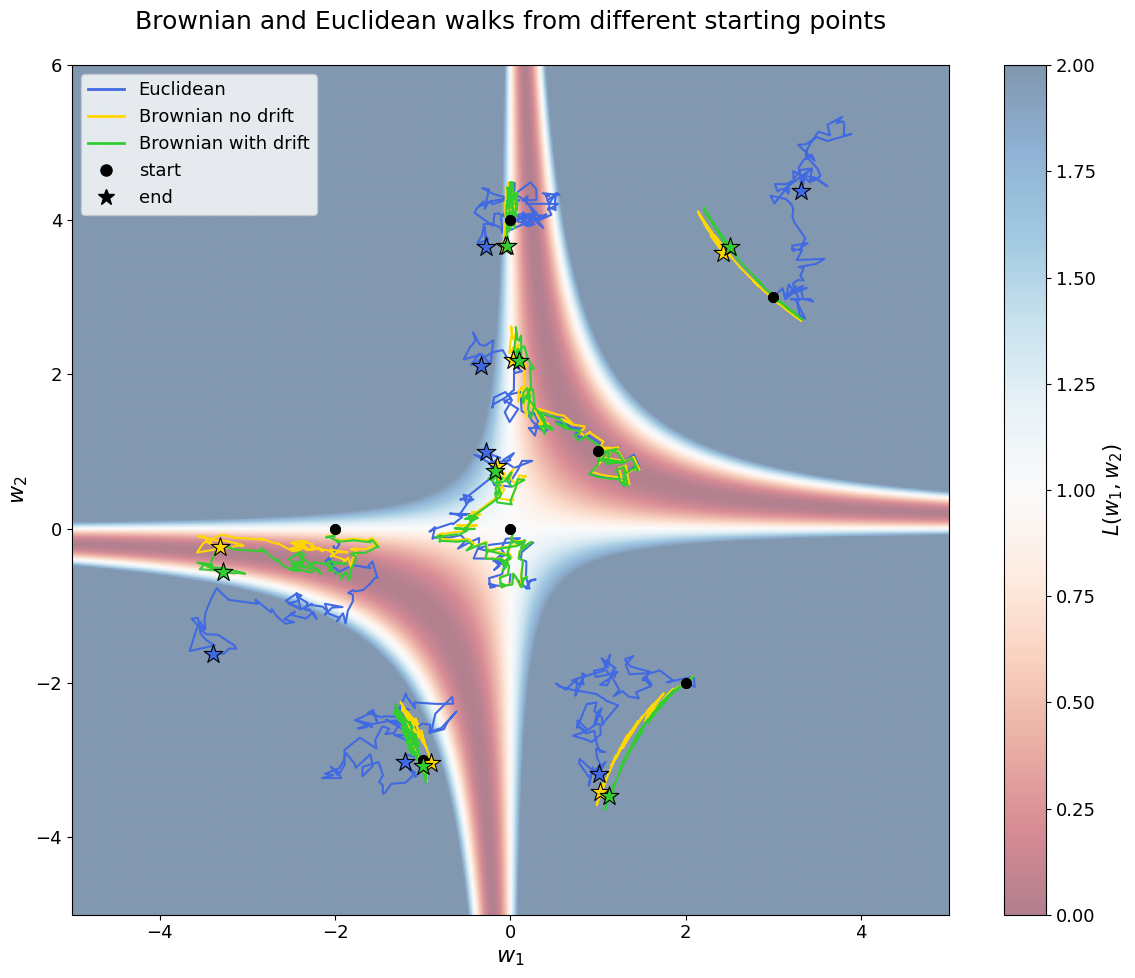

In [10]:
plot_three_walk_types(
    loss_fn=loss_fn,
    metric=metric,
    starts=[(0.0, 0.0), (-2, 0), (2, -2), (1, 1), (0, 4), (-1,-3), (3,3)],
    walk_len=100,
    step_size=0.01,
    seed=2)

In [11]:
def generate_endpoints(metric, start=(1.0,1.0), N=200, walk_len=100, step_size=0.01, seed=7):
    torch.manual_seed(seed)
    np.random.seed(seed)

    sampler_eu = Euclidean_sampler(walk_len=walk_len, step_size=step_size, n_samples=1)
    sampler = Brownian_sampler(metric, walk_len=walk_len, step_size=step_size, n_samples=1)

    startp = torch.tensor(start, dtype=torch.float64)
    seeds = np.floor(100000 * np.random.rand(N)).astype(int)

    eu = np.zeros((N,2))
    no_drift = np.zeros((N,2))
    drift = np.zeros((N,2))

    for i in range(N):
        eu_i = sampler_eu.sample_q_endpoints(startp, drift=False, random_state=int(seeds[i])).detach().numpy()
        no = sampler.sample_q_endpoints(startp, drift=False, random_state=int(seeds[i])).detach().numpy()
        dr = sampler.sample_q_endpoints(startp, drift=True, random_state=int(seeds[i])).detach().numpy()

        eu[i] = eu_i[0]
        no_drift[i] = no[0]
        drift[i] = dr[0]

    return eu, no_drift, drift

eu_ep, no_drift_ep, drift_ep = generate_endpoints(metric, N=300)

KeyboardInterrupt: 

In [ ]:
# sampler_eu = Euclidean_sampler(walk_len=100, step_size=0.01, n_samples=300)
# sampler    = Brownian_sampler(metric, walk_len=100, step_size=0.01, n_samples=300)
# startp     = torch.tensor((1.0, 1.0), dtype=torch.float64)
# 
# eu_ep       = sampler_eu.sample_q_endpoints(startp, drift=False).detach().numpy()
# no_drift_ep = sampler.sample_q_endpoints(startp, drift=False).detach().numpy()
# drift_ep    = sampler.sample_q_endpoints(startp, drift=True).detach().numpy()

In [ ]:
def plot_endpoints(loss_fct, eu_ep, no_drift_ep, drift_ep, start=(1.0,1.0)):

    startp = torch.tensor(start, dtype=torch.float64)

    plt.figure(figsize=(11, 9))

    w1 = np.linspace(-5,5,500)
    w2 = np.linspace(-5,5,500)
    W1, W2 = np.meshgrid(w1, w2)
    # Loss = loss_fct([W1, W2])
    Loss = banana_loss_surface(loss_fn, W1, W2)

    im = plt.imshow(Loss,extent=[w1.min(), w1.max(), w2.min(), w2.max()],origin="lower",aspect="auto",cmap="RdBu",alpha=0.5,vmin=0,vmax=2)

    cbar = plt.colorbar(im)
    cbar.set_label(r"$L(w_1,w_2)$", fontsize=15)
    cbar.ax.tick_params(labelsize=13)

    plt.scatter(start[0], start[1], c="black", s=80, label="start")

    plt.scatter(eu_ep[:, 0], eu_ep[:, 1],c="royalblue",s=45,alpha=0.9,label="Euclidean")

    plt.scatter(no_drift_ep[:, 0], no_drift_ep[:, 1],c="gold",s=45,alpha=0.9,label="Brownian no drift")

    plt.scatter(drift_ep[:, 0], drift_ep[:, 1],c="limegreen",s=45,alpha=0.9,label="Brownian with drift")

    plt.xlabel(r"$w_1$", fontsize=16)
    plt.ylabel(r"$w_2$", fontsize=16)
    plt.title("Endpoints from Brownian and Euclidean walks\n", fontsize=18)

    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13)
    plt.legend(loc="lower left", fontsize=13, frameon=True)

    plt.xlim([-5,5])
    plt.ylim([-5,5])
    plt.tight_layout()
    plt.show()
    

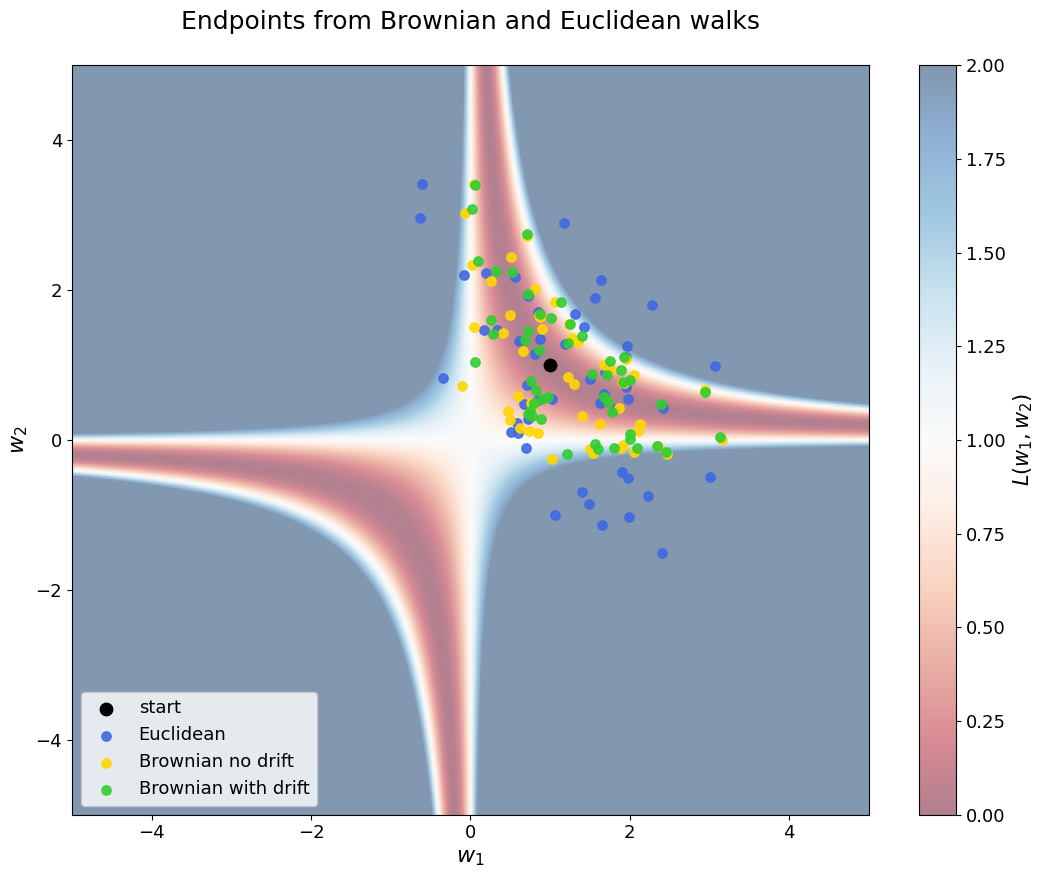

In [ ]:
# idx = np.random.choice(len(no_drift_ep), 50, replace=False)

eu_ep_50       = eu_ep[:50]
no_drift_ep_50 = no_drift_ep[:50]
drift_ep_50    = drift_ep[:50]

plot_endpoints(
    loss_fct=loss_fn,
    eu_ep=eu_ep_50,
    no_drift_ep=no_drift_ep_50,
    drift_ep=drift_ep_50,
    start=(1.0,1.0))

In [ ]:
def plot_vertical_endpoints(loss_fct, eu_ep, no_drift_ep, drift_ep):

    fig, axes = plt.subplots(3, 1, figsize=(7, 15))  # vertical

    titles = ["Euclidean Motion", "Brownian no drift", "Brownian with drift"]
    datasets = [eu_ep, no_drift_ep, drift_ep]
    colors = ["royalblue", "gold", "limegreen"]

    for ax, data, title, col in zip(axes, datasets, titles, colors):

        plt.sca(ax)

        w1 = np.linspace(-5,5,500)
        w2 = np.linspace(-5,5,500)
        W1, W2 = np.meshgrid(w1, w2)
        # Loss = loss_fct([W1, W2])
        Loss = banana_loss_surface(loss_fn, W1, W2)

        im = ax.imshow(Loss,extent=[w1.min(), w1.max(), w2.min(), w2.max()],origin="lower",cmap="RdBu",alpha=0.5, vmin=0, vmax=2)

        ax.scatter(data[:,0], data[:,1], c=col, s=12, alpha=0.85, label=title)

        ax.scatter(1,1, c="black", s=60)

        # ax.set_title(title, fontsize=16)
        ax.set_xlabel(r"$w_1$", fontsize=16)
        ax.set_ylabel(r"$w_2$", fontsize=16)

        ax.legend(loc="lower left")

    #fig.colorbar(im, ax=axes, shrink=0.6, label=r"$L(w_1,w_2)$")

    plt.tight_layout()
    plt.show()

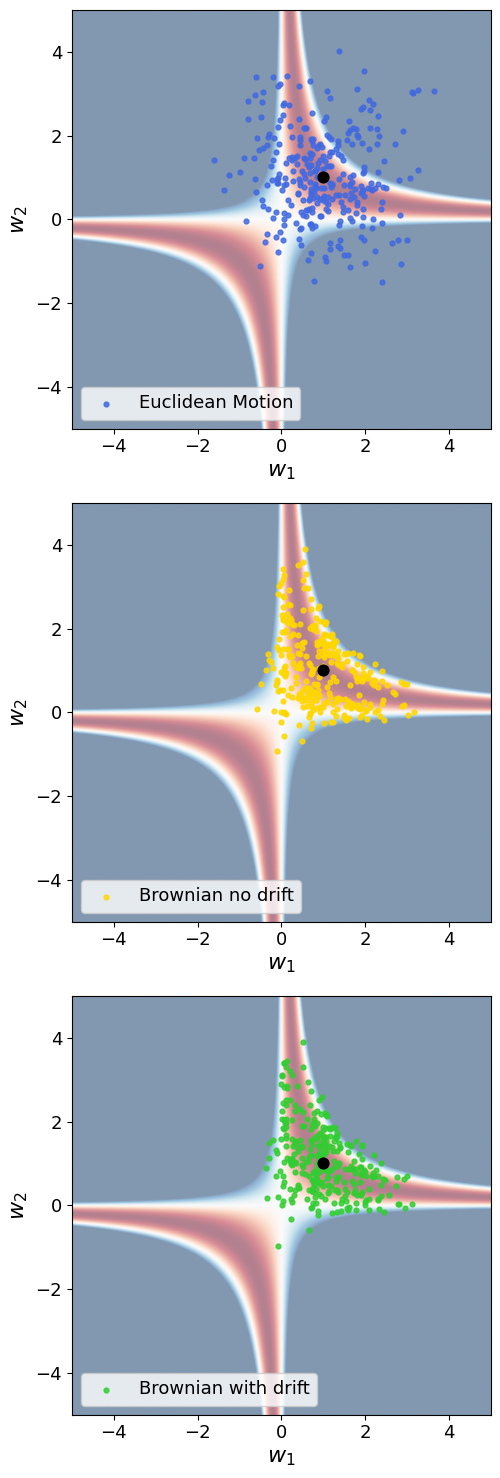

In [ ]:
plot_vertical_endpoints(loss_fn, eu_ep, no_drift_ep, drift_ep)